# Setup & Config

In [1]:
"""
Phase 1 Data Pipeline: Taxonomy Remap + Dedup + Clean-Negative Injection + YOLO-seg Export
Run from project root. All paths are relative.
"""
import json
import hashlib
import shutil
from pathlib import Path
from collections import Counter, defaultdict
from tqdm import tqdm

def md5_file(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

# ─── Paths (relative to project root) ─────────────────────────────────────────
RAW_DIR = Path("../data/raw")
OUTPUT_DIR = Path("../data/processed")
ANN_DIR = OUTPUT_DIR / "annotations"
IMG_DIR = OUTPUT_DIR / "images"
YOLO_DIR = OUTPUT_DIR / "yolo_seg"

# ─── 7-Class Unified Taxonomy ─────────────────────────────────────────────────
UNIFIED_CLASSES = [
    "broken_lamp",
    "corrosion",
    "crack",
    "dent",
    "disjoint_part",
    "glass_shatter",
    "scratch",
]

CLASS_MAPPING = {
    "dent": "dent",
    "ding": "dent",
    "deform": "dent",
    "scratch": "scratch",
    "scratch_hairline": "scratch",
    "scratch_gouge": "scratch",
    "crack": "crack",
    "crack-4VtJ": "crack",
    "glass shatter": "glass_shatter",
    "glass_shatter": "glass_shatter",
    "lamp broken": "broken_lamp",
    "broken_lamp": "broken_lamp",
    "corrosion": "corrosion",
    "rust": "corrosion",
    "Rust": "corrosion",
    "copper corrosion": "corrosion",
    "corroded-part": "corrosion",
    "iron rust": "corrosion",
    "mild-corrosion": "corrosion",
    "moderate-corrosion": "corrosion",
    "severe-corrosion": "corrosion",
    "broken_components": "disjoint_part",
    "disjoint_part": "disjoint_part",
}

# Per-source overrides: 'car' in Rust Detection means corroded bodywork
SOURCE_CLASS_OVERRIDES = {
    "Rust Detection.v1i.coco": {"car": "corrosion"},
}

# Known duplicate to exclude
EXCLUDED_DATASETS = {"car-damage-detection.v1i.coco"}

# ─── Config ────────────────────────────────────────────────────────────────────
COPY_IMAGES = True          # True = copy files (safe for cross-machine), False = symlink
CLEAN_NEGATIVE_RATIO = 0.12 # 12% of training images should be clean negatives
CLEAN_IMG_DIR = Path("../data/raw/clean_cars")  # ← put clean images here later
CD2200_REANNOTATED_COUNT = 2200 
EXCLUDED_DATASETS.add("Car defect 2000 new") 
BBOX_TO_POLYGON_FALLBACK = True
SUPERVISELY_DIR = RAW_DIR / "archive" / "Car parts dataset" / "File1"
SUPERVISELY_CLASS_MAPPING = {
    "Scratch": "scratch",
    "Dent": "dent",
    "Broken part": "disjoint_part",
    "Corrosion": "corrosion",
    "Cracked": "crack",
}
SUPERVISELY_MIN_POLY_AREA = 10.0
RUST_MAX_TRAIN_IMAGES = 2500
RUST_FULL_FRAME_DROP = 0.90

print("Config loaded.")
print(f"  RAW_DIR:    {RAW_DIR}")
print(f"  OUTPUT_DIR: {OUTPUT_DIR}")
print(f"  Classes:    {UNIFIED_CLASSES}")

Config loaded.
  RAW_DIR:    ../data/raw
  OUTPUT_DIR: ../data/processed
  Classes:    ['broken_lamp', 'corrosion', 'crack', 'dent', 'disjoint_part', 'glass_shatter', 'scratch']


# Cell 2 — Discover & Load COCO Sources

In [2]:
def load_coco(json_path):
    """Load a COCO JSON file, return None if invalid."""
    try:
        with open(json_path, "r") as f:
            data = json.load(f)
    except (OSError, json.JSONDecodeError) as exc:
        print(f"    [warn] cannot read {json_path}: {exc}")
        return None
    if not isinstance(data, dict) or "images" not in data or "annotations" not in data:
        print(f"    [warn] not a COCO instances file: {json_path}")
        return None
    return data


def discover_sources(raw_dir):
    """Scan data/raw/ for all COCO annotation sources."""
    sources = []

    # CarDD_COCO (official splits)
    cardd = raw_dir / "CarDD_release" / "CarDD_COCO"
    for split, subdir in (("train", "train2017"), ("val", "val2017"), ("test", "test2017")):
        ann = cardd / "annotations" / f"instances_{subdir}.json"
        if ann.exists():
            sources.append({"name": "CarDD_COCO", "json": ann, "images_dir": cardd / subdir, "split": split})

    # Car defect 2200 only (2000 new is a duplicate superset → excluded)
    for folder in ("Car defect 2200",):
        ann = raw_dir / folder / "annotations" / "instances_default.json"
        if ann.exists():
            sources.append({"name": folder, "json": ann, "images_dir": raw_dir / folder / "images" / "default", "split": None})

    # Roboflow exports
    roboflow = raw_dir / "Roboflow"
    if roboflow.is_dir():
        for export in sorted(roboflow.iterdir()):
            if not export.is_dir() or export.name in EXCLUDED_DATASETS:
                continue
            for split, subdir in (("train", "train"), ("val", "valid"), ("test", "test")):
                ann = export / subdir / "_annotations.coco.json"
                if ann.exists():
                    sources.append({"name": export.name, "json": ann, "images_dir": export / subdir, "split": split})

    return sources


sources = discover_sources(RAW_DIR)
print(f"Discovered {len(sources)} COCO source(s):")
for s in sources:
    print(f"  • {s['name']:40s} split={str(s['split']):5s}  json={s['json'].name}")

Discovered 19 COCO source(s):
  • CarDD_COCO                               split=train  json=instances_train2017.json
  • CarDD_COCO                               split=val    json=instances_val2017.json
  • CarDD_COCO                               split=test   json=instances_test2017.json
  • Car defect 2200                          split=None   json=instances_default.json
  • Car Defect Detection.coco-segmentation   split=train  json=_annotations.coco.json
  • Car Defect Detection.coco-segmentation   split=val    json=_annotations.coco.json
  • Car Defect Detection.coco-segmentation   split=test   json=_annotations.coco.json
  • Rust Detection.v1i.coco                  split=train  json=_annotations.coco.json
  • Rust Detection.v1i.coco                  split=val    json=_annotations.coco.json
  • Rust Detection.v1i.coco                  split=test   json=_annotations.coco.json
  • car defect.v1i.coco                      split=train  json=_annotations.coco.json
  • car defect.v1i.co

In [3]:
# ─── Build CarDD MD5 → split lookup for split inheritance ────────────────────
def build_cardd_split_lookup(raw_dir):
    """Hash all CarDD images and map MD5 → original split (train/val/test)."""
    cardd_base = raw_dir / "CarDD_release" / "CarDD_COCO"
    lookup = {}  # md5 → split
    for split, subdir in (("train", "train2017"), ("val", "val2017"), ("test", "test2017")):
        img_dir = cardd_base / subdir
        if not img_dir.is_dir():
            continue
        for p in tqdm(sorted(img_dir.iterdir()), desc=f"Hashing CarDD {split}", unit="img"):
            if p.suffix.lower() in (".jpg", ".jpeg", ".png"):
                lookup[md5_file(p)] = split
    print(f"  CarDD split lookup: {len(lookup)} images hashed")
    return lookup

cardd_split_lookup = build_cardd_split_lookup(RAW_DIR)


Hashing CarDD train:   0%|          | 0/2816 [00:00<?, ?img/s]


Hashing CarDD train:   2%|▏         | 53/2816 [00:00<00:05, 525.83img/s]


Hashing CarDD train:   4%|▍         | 107/2816 [00:00<00:05, 527.90img/s]


Hashing CarDD train:   6%|▌         | 160/2816 [00:00<00:05, 463.23img/s]


Hashing CarDD train:   7%|▋         | 209/2816 [00:00<00:05, 471.88img/s]

...


Hashing CarDD test:  72%|███████▏  | 269/374 [00:00<00:00, 499.51img/s]


Hashing CarDD test:  86%|████████▌ | 322/374 [00:00<00:00, 508.47img/s]


Hashing CarDD test: 100%|██████████| 374/374 [00:00<00:00, 511.31img/s]


Hashing CarDD test: 100%|██████████| 374/374 [00:00<00:00, 499.48img/s]

  CarDD split lookup: 4000 images hashed


# Cell 3 — Taxonomy Remap & Process

In [4]:
def split_from_filename(file_name):
    """Infer split from filename prefix (for sources without explicit splits)."""
    parts = file_name.split("_")
    if len(parts) >= 2 and parts[0] in ("cardd", "rust"):
        return {"train": "train", "val": "val", "test": "test"}.get(parts[1], "train")
    return "train"


def process_source(src):
    """Load one COCO source, remap classes to 7-class taxonomy, return entries."""
    stats = Counter()
    data = load_coco(src["json"])
    if data is None:
        return [], stats

    overrides = SOURCE_CLASS_OVERRIDES.get(src["name"], {})
    cat_to_unified = {}
    for cat in data.get("categories", []):
        target = overrides.get(cat["name"], CLASS_MAPPING.get(cat["name"]))
        if target in UNIFIED_CLASSES:
            cat_to_unified[cat["id"]] = UNIFIED_CLASSES.index(target) + 1  # 1-indexed

    anns_by_image = defaultdict(list)
    for ann in data.get("annotations", []):
        unified_id = cat_to_unified.get(ann.get("category_id"))
        if unified_id is None:
            stats["anns_dropped_unmapped"] += 1
            continue
        seg = ann.get("segmentation", [])
        bbox = ann.get("bbox", [])
        area = ann.get("area", 0)

        # BBox-to-Polygon fallback: synthesize rectangular polygon from bbox
        if BBOX_TO_POLYGON_FALLBACK and (not seg or seg == [] or seg == [[]]) and len(bbox) == 4:
            x, y, w, h = bbox
            if w > 0 and h > 0:
                seg = [[x, y, x + w, y, x + w, y + h, x, y + h]]
                if area == 0:
                    area = w * h
                stats["bbox_to_polygon_fallback"] += 1

        anns_by_image[ann.get("image_id")].append(
            {
                "category_id": unified_id,
                "segmentation": seg,
                "area": area,
                "bbox": bbox,
                "iscrowd": ann.get("iscrowd", 0),
            }
        )

    images_list = data.get("images", [])
    if src["name"] == "Car defect 2200":
        images_list = images_list[:CD2200_REANNOTATED_COUNT]
        print(f"    [info] Truncated to first {CD2200_REANNOTATED_COUNT} re-annotated images")

    entries = []
    for im in images_list:
        kept = anns_by_image.get(im.get("id"))
        if not kept:
            stats["images_without_kept_anns"] += 1
            continue
        path = src["images_dir"] / im.get("file_name", "")
        if not path.is_file():
            stats["images_missing_on_disk"] += 1
            continue
        entries.append({
            "source": src["name"],
            "path": path,
            "split": src["split"] or split_from_filename(im.get("file_name", "")),
            "width": im.get("width"),
            "height": im.get("height"),
            "annotations": kept,
        })
    stats["images_kept"] = len(entries)
    return entries, stats


# Process all sources
all_entries = []
totals = Counter()
for src in sources:
    entries, stats = process_source(src)
    all_entries.extend(entries)
    totals.update(stats)
    print(f"[{src['name']}] kept={stats['images_kept']}  "
            f"dropped_unmapped={stats['anns_dropped_unmapped']}  "
            f"no_anns={stats['images_without_kept_anns']}  "
            f"missing={stats['images_missing_on_disk']}  "
            f"bbox_fallback={stats.get('bbox_to_polygon_fallback', 0)}")

print(f"\nTotal candidate images: {len(all_entries)}")

[CarDD_COCO] kept=2644  dropped_unmapped=225  no_anns=172  missing=0  bbox_fallback=0
[CarDD_COCO] kept=768  dropped_unmapped=62  no_anns=42  missing=0  bbox_fallback=0


[CarDD_COCO] kept=349  dropped_unmapped=32  no_anns=25  missing=0  bbox_fallback=0


    [info] Truncated to first 2200 re-annotated images
[Car defect 2200] kept=2019  dropped_unmapped=0  no_anns=181  missing=0  bbox_fallback=829


[Car Defect Detection.coco-segmentation] kept=0  dropped_unmapped=16814  no_anns=8566  missing=0  bbox_fallback=0
[Car Defect Detection.coco-segmentation] kept=0  dropped_unmapped=1669  no_anns=826  missing=0  bbox_fallback=0
[Car Defect Detection.coco-segmentation] kept=0  dropped_unmapped=886  no_anns=422  missing=0  bbox_fallback=0


[Rust Detection.v1i.coco] kept=8795  dropped_unmapped=0  no_anns=677  missing=0  bbox_fallback=32094
[Rust Detection.v1i.coco] kept=248  dropped_unmapped=0  no_anns=47  missing=0  bbox_fallback=725
[Rust Detection.v1i.coco] kept=244  dropped_unmapped=0  no_anns=52  missing=0  bbox_fallback=736


[car defect.v1i.coco] kept=0  dropped_unmapped=30065  no_anns=4901  missing=0  bbox_fallback=0
[car defect.v1i.coco] kept=0  dropped_unmapped=6024  no_anns=1052  missing=0  bbox_fallback=0


[car defect.v1i.coco] kept=0  dropped_unmapped=6065  no_anns=1047  missing=0  bbox_fallback=0
[crack_v2.v1i.coco] kept=0  dropped_unmapped=570  no_anns=290  missing=0  bbox_fallback=0
[crack_v2.v1i.coco] kept=0  dropped_unmapped=176  no_anns=93  missing=0  bbox_fallback=0
[crack_v2.v1i.coco] kept=0  dropped_unmapped=71  no_anns=31  missing=0  bbox_fallback=0


[socarC.v1i.coco] kept=0  dropped_unmapped=65599  no_anns=21260  missing=0  bbox_fallback=0
[socarC.v1i.coco] kept=0  dropped_unmapped=7727  no_anns=2470  missing=0  bbox_fallback=0
[socarC.v1i.coco] kept=0  dropped_unmapped=3053  no_anns=986  missing=0  bbox_fallback=0

Total candidate images: 15067


# Cell 3b — Supervisely "Car parts" conversion (Mode A)

In [5]:
def shoelace_area(pts):
    """pts: list of [x, y] pairs → absolute polygon area."""
    n = len(pts)
    if n < 3:
        return 0.0
    area = 0.0
    for i in range(n):
        x1, y1 = pts[i]
        x2, y2 = pts[(i + 1) % n]
        area += x1 * y2 - x2 * y1
    return abs(area) / 2.0


def process_supervisely(src_dir):
    stats = Counter()
    entries = []
    for ann_file in sorted((src_dir / "ann").glob("*.json")):
        img_path = src_dir / "img" / ann_file.name[: -len(".json")]
        if not img_path.is_file():
            stats["images_missing_on_disk"] += 1
            continue
        with open(ann_file, "r") as f:
            data = json.load(f)

        kept_anns = []
        for obj in data.get("objects", []):
            target = SUPERVISELY_CLASS_MAPPING.get(obj.get("classTitle", ""))
            if target is None:
                stats["anns_dropped_unmapped"] += 1
                continue
            if obj.get("geometryType") != "polygon":
                stats["anns_dropped_non_polygon"] += 1
                continue
            exterior = obj.get("points", {}).get("exterior", [])
            if len(exterior) < 3:
                stats["anns_dropped_degenerate"] += 1
                continue
            area = shoelace_area(exterior)
            if area < SUPERVISELY_MIN_POLY_AREA:
                stats["anns_dropped_tiny"] += 1
                continue

            flat_poly = [c for xy in exterior for c in (float(xy[0]), float(xy[1]))]
            xs = [p[0] for p in exterior]
            ys = [p[1] for p in exterior]
            kept_anns.append({
                "category_id": UNIFIED_CLASSES.index(target) + 1,
                "segmentation": [flat_poly],   # exterior only; holes ignored
                "area": area,
                "bbox": [min(xs), min(ys), max(xs) - min(xs), max(ys) - min(ys)],
                "iscrowd": 0,
            })

        if not kept_anns:
            stats["images_without_kept_anns"] += 1
            continue
        entries.append({
            "source": "Car parts (Supervisely)",
            "path": img_path,
            "split": "train",   # no native splits; dedup + leakage check guard this
            "width": data.get("size", {}).get("width"),
            "height": data.get("size", {}).get("height"),
            "annotations": kept_anns,
        })

    stats["images_kept"] = len(entries)
    return entries, stats


supervisely_entries, sup_stats = process_supervisely(SUPERVISELY_DIR)
all_entries.extend(supervisely_entries)

print(f"[Car parts (Supervisely)] kept={sup_stats['images_kept']}  "
      f"dropped_unmapped={sup_stats['anns_dropped_unmapped']}  "
      f"dropped_tiny={sup_stats['anns_dropped_tiny']}  "
      f"dropped_degenerate={sup_stats['anns_dropped_degenerate']}  "
      f"no_anns={sup_stats['images_without_kept_anns']}  "
      f"missing={sup_stats['images_missing_on_disk']}")

sup_cls = Counter(UNIFIED_CLASSES[a["category_id"] - 1]
                  for e in supervisely_entries for a in e["annotations"])
print("  Kept annotations by class:", dict(sorted(sup_cls.items())))
print(f"Total candidate images now: {len(all_entries)}")

[Car parts (Supervisely)] kept=806  dropped_unmapped=2325  dropped_tiny=119  dropped_degenerate=0  no_anns=8  missing=0
  Kept annotations by class: {'corrosion': 277, 'crack': 76, 'dent': 1650, 'disjoint_part': 1500, 'scratch': 3137}
Total candidate images now: 15873


# Cell 3c — Rust Detection curation (rebalance train) 


In [6]:
CORROSION_ID = UNIFIED_CLASSES.index("corrosion") + 1

def poly_is_rect(p):
    xs = {round(p[i], 2) for i in range(0, len(p), 2)}
    ys = {round(p[i], 2) for i in range(1, len(p), 2)}
    return len(xs) <= 2 and len(ys) <= 2

def pixel_area_share(entries):
    per_class = Counter()
    for e in entries:
        for a in e["annotations"]:
            per_class[a["category_id"]] += a.get("area", 0)
    total = sum(per_class.values()) or 1
    return {UNIFIED_CLASSES[c-1]: 100*v/total for c, v in per_class.items()}, total

train_only = [e for e in all_entries if e["split"] == "train"]
before_share, before_total = pixel_area_share(train_only)

dropped_fullframe = 0
curated, rust_entries = [], []
for e in all_entries:
    if e["source"] == "Rust Detection.v1i.coco" and e["split"] == "train":
        w_img, h_img = e["width"] or 1, e["height"] or 1
        kept_anns = []
        for a in e["annotations"]:
            bbox_area = a["bbox"][2] * a["bbox"][3] if len(a["bbox"]) == 4 else 0
            seg = a["segmentation"]
            poly = seg[0] if isinstance(seg, list) and seg and isinstance(seg[0], list) else seg
            if (a["category_id"] == CORROSION_ID and isinstance(poly, list)
                    and poly_is_rect(poly) and bbox_area / (w_img * h_img) >= RUST_FULL_FRAME_DROP):
                dropped_fullframe += 1
                continue
            kept_anns.append(a)
        if not kept_anns:
            continue  # image lost all its annotations
        rust_entries.append({**e, "annotations": kept_anns})
    else:
        curated.append(e)

# Cap rust images: keep the 2,500 with smallest relative corrosion bbox
def rust_size_score(e):
    ratios = [a["bbox"][2] * a["bbox"][3] / ((e["width"] or 1) * (e["height"] or 1))
              for a in e["annotations"]
              if a["category_id"] == CORROSION_ID and len(a["bbox"]) == 4]
    return max(ratios) if ratios else 0.0

rust_entries.sort(key=rust_size_score)
dropped_by_cap = max(0, len(rust_entries) - RUST_MAX_TRAIN_IMAGES)
curated.extend(rust_entries[:RUST_MAX_TRAIN_IMAGES])
all_entries[:] = curated

after_share, after_total = pixel_area_share([e for e in all_entries if e["split"] == "train"])
print(f"Rust curation: dropped {dropped_fullframe} full-frame rect corrosion anns; "
      f"{dropped_by_cap} rust images by cap (kept {min(len(rust_entries), RUST_MAX_TRAIN_IMAGES)})")
print(f"\nPer-class pixel-area share (train) BEFORE → AFTER:")
for cls in UNIFIED_CLASSES:
    print(f"  {cls:>15s}: {before_share.get(cls, 0):5.1f}% → {after_share.get(cls, 0):5.1f}%")
print(f"Total train mask pixels: {before_total:,.0f} → {after_total:,.0f}")
print(f"Total candidate images now: {len(all_entries)}")

Rust curation: dropped 95 full-frame rect corrosion anns; 6206 rust images by cap (kept 2500)

Per-class pixel-area share (train) BEFORE → AFTER:
      broken_lamp:   4.7% →  11.4%
        corrosion:  63.6% →  12.6%
            crack:   0.3% →   0.7%
             dent:   9.7% →  23.4%
    disjoint_part:   0.9% →   2.3%
    glass_shatter:  11.4% →  27.4%
          scratch:   9.3% →  22.2%
Total train mask pixels: 1,977,945,367 → 823,946,774
Total candidate images now: 9578


# Cell 4 — MD5 Deduplication

In [7]:
def deduplicate(entries, cardd_lookup):
    """Deduplicate by MD5. Car defect 2200 re-annotations win over CarDD originals,
    but inherit the CarDD split to prevent test leakage."""
    by_hash = {}
    cross_split = 0
    split_inherited = 0

    for entry in tqdm(entries, desc="Hashing images", unit="img"):
        digest = md5_file(entry["path"])
        entry["md5"] = digest

        # Inherit CarDD split if this image matches a CarDD original
        if digest in cardd_lookup:
            inherited_split = cardd_lookup[digest]
            if entry["source"] == "Car defect 2200":
                entry["split"] = inherited_split
                split_inherited += 1

        current = by_hash.get(digest)
        if current is None:
            by_hash[digest] = entry
            continue

        if current["split"] != entry["split"]:
            cross_split += 1

        # Priority: Car defect 2200 (re-annotated) > CarDD_COCO > others
        def priority(e):
            if e["source"] == "Car defect 2200":
                return 3
            elif e["source"] == "CarDD_COCO":
                return 2
            else:
                return 1

        if priority(entry) > priority(current):
            # Keep new entry but inherit split from CarDD if available
            if digest in cardd_lookup:
                entry["split"] = cardd_lookup[digest]
            by_hash[digest] = entry
        elif priority(entry) == priority(current):
            # Same priority: keep the one with more annotations
            if len(entry["annotations"]) > len(current["annotations"]):
                if digest in cardd_lookup:
                    entry["split"] = cardd_lookup[digest]
                by_hash[digest] = entry

    print(f"  Split inherited from CarDD: {split_inherited}")
    if cross_split:
        print(f"  [warn] {cross_split} duplicate(s) span multiple splits")
    return list(by_hash.values())


kept = deduplicate(all_entries, cardd_split_lookup)
print(f"Unique images after dedup: {len(kept)}  (removed {len(all_entries) - len(kept)} duplicates)")


Hashing images:   0%|          | 0/9578 [00:00<?, ?img/s]


Hashing images:   1%|          | 57/9578 [00:00<00:16, 563.74img/s]


Hashing images:   1%|          | 114/9578 [00:00<00:17, 543.20img/s]


Hashing images:   2%|▏         | 169/9578 [00:00<00:17, 528.27img/s]


Hashing images:   2%|▏         | 222/9578 [00:00<00:18, 499.02img/s]

...


Hashing images:  94%|█████████▍| 9042/9578 [00:13<00:00, 2223.62img/s]


Hashing images:  97%|█████████▋| 9268/9578 [00:13<00:00, 2065.15img/s]


Hashing images: 100%|█████████▉| 9544/9578 [00:13<00:00, 2253.71img/s]


Hashing images: 100%|██████████| 9578/9578 [00:13<00:00, 704.05img/s] 

  Split inherited from CarDD: 2019
  [warn] 22 duplicate(s) span multiple splits
Unique images after dedup: 7340  (removed 2238 duplicates)


# Cell 5 — Write Unified COCO JSONs + Images

In [8]:
def slug(name):
    return "".join(ch if ch.isalnum() or ch in "-." else "_" for ch in name)


def write_split(split, entries, ann_dir, img_root, copy_images):
    """Write one split's COCO JSON and populate image directory."""
    split_dir = img_root / split
    if split_dir.exists():
        shutil.rmtree(split_dir)
    split_dir.mkdir(parents=True)

    categories = [{"id": i + 1, "name": name} for i, name in enumerate(UNIFIED_CLASSES)]
    images, annotations = [], []
    taken_names = set()

    for new_id, entry in enumerate(sorted(entries, key=lambda e: str(e["path"])), start=1):
        file_name = entry["path"].name
        if file_name in taken_names:
            file_name = f"{slug(entry['source'])}__{file_name}"
        taken_names.add(file_name)

        if copy_images:
            shutil.copy2(entry["path"], split_dir / file_name)
        else:
            (split_dir / file_name).symlink_to(entry["path"].resolve())

        images.append({"id": new_id, "file_name": file_name, "width": entry["width"], "height": entry["height"]})
        for ann in entry["annotations"]:
            annotations.append({
                "id": len(annotations) + 1,
                "image_id": new_id,
                "category_id": ann["category_id"],
                "segmentation": ann["segmentation"],
                "area": ann["area"],
                "bbox": ann["bbox"],
                "iscrowd": ann["iscrowd"],
            })

    with open(ann_dir / f"{split}.json", "w") as f:
        json.dump({"images": images, "annotations": annotations, "categories": categories}, f)

    class_counts = Counter(a["category_id"] for a in annotations)
    per_class = ", ".join(f"{UNIFIED_CLASSES[cid-1]}={n}" for cid, n in sorted(class_counts.items()))
    print(f"  {split:<5} images={len(images):>6}  anns={len(annotations):>7}  [{per_class}]")


# Group by split
by_split = defaultdict(list)
for entry in kept:
    by_split[entry["split"]].append(entry)

# Write
ANN_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)

print("Writing unified COCO dataset:")
for split in ("train", "val", "test"):
    write_split(split, by_split.get(split, []), ANN_DIR, IMG_DIR, COPY_IMAGES)

Writing unified COCO dataset:


  train images=  5734  anns=  28237  [broken_lamp=502, corrosion=14704, crack=765, dent=3458, disjoint_part=1905, glass_shatter=477, scratch=6426]


  val   images=  1013  anns=   2789  [broken_lamp=141, corrosion=1107, crack=177, dent=501, glass_shatter=135, scratch=728]


  test  images=   593  anns=   2472  [broken_lamp=75, corrosion=1215, crack=86, dent=255, disjoint_part=96, glass_shatter=71, scratch=674]


# Cell 6 — Clean-Negative Injection


In [9]:
def inject_clean_negatives(ann_dir, img_root, clean_dir, ratio, copy_images=True):
    """
    Add clean (undamaged) car images with empty annotations to the training set.
    Skips gracefully if clean_dir doesn't exist or is empty.
    """
    if not clean_dir.exists() or not any(clean_dir.iterdir()):
        print(f"  [SKIP] Clean image directory not found or empty: {clean_dir}")
        print(f"         Download clean car images and place them there, then re-run this cell.")
        print(f"         Suggested sources (see STAGE2_RETRAIN_BRIEF.md §3):")
        print(f"           • Kaggle 'anujms/car-damage-detection' → 'whole' class")
        print(f"           • CarDD '500 undamaged' set (if downloadable)")
        print(f"           • Stanford Cars / CompCars (filtered slice)")
        return

    # Load existing train annotations to determine how many negatives to add
    train_json = ann_dir / "train.json"
    with open(train_json, "r") as f:
        train_data = json.load(f)

    n_existing = len(train_data["images"])
    n_negatives_target = int(n_existing * ratio / (1 - ratio))  # negatives as fraction of total

    # Gather clean images
    clean_images = sorted(
        p for p in clean_dir.iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    )

    if len(clean_images) == 0:
        print(f"  [SKIP] No image files found in {clean_dir}")
        return

    # Use up to n_negatives_target images
    selected = clean_images[:n_negatives_target]
    print(f"  Injecting {len(selected)} clean negatives into train split "
          f"(target ratio: {ratio:.0%}, existing train images: {n_existing})")

    # Copy/symlink images
    train_img_dir = img_root / "train"
    next_id = max(im["id"] for im in train_data["images"]) + 1
    taken_names = {im["file_name"] for im in train_data["images"]}

    for img_path in selected:
        file_name = f"clean__{img_path.name}"
        if file_name in taken_names:
            continue
        taken_names.add(file_name)

        if copy_images:
            shutil.copy2(img_path, train_img_dir / file_name)
        else:
            (train_img_dir / file_name).symlink_to(img_path.resolve())

        # Add image entry with NO annotations (empty = negative)
        from PIL import Image
        with Image.open(img_path) as im:
            w, h = im.size
        train_data["images"].append({
            "id": next_id, "file_name": file_name, "width": w, "height": h
        })
        next_id += 1

    # Overwrite train.json
    with open(train_json, "w") as f:
        json.dump(train_data, f)

    print(f"  Done. Train split now has {len(train_data['images'])} images "
          f"({len(selected)} clean negatives).")


print("Clean-negative injection:")
inject_clean_negatives(ANN_DIR, IMG_DIR, CLEAN_IMG_DIR, CLEAN_NEGATIVE_RATIO, COPY_IMAGES)

Clean-negative injection:
  [SKIP] Clean image directory not found or empty: ../data/raw/clean_cars
         Download clean car images and place them there, then re-run this cell.
         Suggested sources (see STAGE2_RETRAIN_BRIEF.md §3):
           • Kaggle 'anujms/car-damage-detection' → 'whole' class
           • CarDD '500 undamaged' set (if downloadable)
           • Stanford Cars / CompCars (filtered slice)


# Cell 7 — Convert to YOLO-seg Format


In [130]:
def coco_to_yolo_seg(ann_dir, img_root, yolo_dir, split):
    """Convert one split from COCO JSON → Ultralytics YOLO-seg format."""
    json_path = ann_dir / f"{split}.json"
    if not json_path.exists():
        print(f"  [SKIP] {json_path} not found")
        return

    with open(json_path, "r") as f:
        coco = json.load(f)

    # Build lookup: image_id → image info
    img_lookup = {im["id"]: im for im in coco["images"]}

    # Group annotations by image
    anns_by_img = defaultdict(list)
    for ann in coco["annotations"]:
        anns_by_img[ann["image_id"]].append(ann)

    # Output dirs
    out_img_dir = yolo_dir / "images" / split
    out_lbl_dir = yolo_dir / "labels" / split
    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_lbl_dir.mkdir(parents=True, exist_ok=True)

    n_written = 0
    for im_info in coco["images"]:
        img_id = im_info["id"]
        file_name = im_info["file_name"]
        w_img = im_info["width"]
        h_img = im_info["height"]

        # Symlink or copy image
        src_img = img_root / split / file_name
        dst_img = out_img_dir / file_name
        if not dst_img.exists():
            if COPY_IMAGES:
                shutil.copy2(src_img, dst_img)
            else:
                dst_img.symlink_to(src_img.resolve())

        # Write label file
        label_path = out_lbl_dir / (Path(file_name).stem + ".txt")
        lines = []
        for ann in anns_by_img.get(img_id, []):
            class_id = ann["category_id"] - 1  # 0-indexed for YOLO
            seg = ann.get("segmentation", [])

            # Safety-net fallback: if segmentation is still empty, try bbox
            if (not seg or seg == [] or seg == [[]]):
                bbox = ann.get("bbox", [])
                if BBOX_TO_POLYGON_FALLBACK and len(bbox) == 4:
                    x, y, w, h = bbox
                    if w > 0 and h > 0:
                        seg = [[x, y, x + w, y, x + w, y + h, x, y + h]]
                    else:
                        continue
                else:
                    continue
            if isinstance(seg, dict):
                from pycocotools import mask as mask_utils
                import cv2
                import numpy as np
                if isinstance(seg.get("counts"), list):
                    # Uncompressed RLE → convert to compressed first
                    rle = mask_utils.frPyObjects(seg, seg["size"][0], seg["size"][1])
                else:
                    # Already compressed RLE
                    rle = seg
                binary_mask = mask_utils.decode(rle)
                contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                seg = [c.flatten().tolist() for c in contours if len(c) >= 3]
                if not seg:
                    continue
            for polygon in seg:
                if len(polygon) < 6:  # need at least 3 points
                    continue
                # Normalize to [0, 1]
                norm = []
                for i in range(0, len(polygon), 2):
                    x = float(polygon[i]) / w_img
                    y = float(polygon[i + 1]) / h_img
                    x = max(0.0, min(1.0, x))
                    y = max(0.0, min(1.0, y))
                    norm.append(f"{x:.6f}")
                    norm.append(f"{y:.6f}")
                lines.append(f"{class_id} " + " ".join(norm))

        with open(label_path, "w") as f:
            f.write("\n".join(lines))
        n_written += 1

    print(f"  {split:<5} → {n_written} label files written to {out_lbl_dir}")


def write_data_yaml(yolo_dir, classes):
    """Write Ultralytics data.yaml."""
    yaml_content = f"""# Auto-generated by phase1_data_pipeline.ipynb
path: {yolo_dir}
train: images/train
val: images/val
test: images/test

names:
"""
    for i, name in enumerate(classes):
        yaml_content += f"  {i}: {name}\n"

    with open(yolo_dir / "data.yaml", "w") as f:
        f.write(yaml_content)
    print(f"  data.yaml written → {yolo_dir / 'data.yaml'}")


# Run conversion
print("Converting to YOLO-seg format:")
YOLO_DIR.mkdir(parents=True, exist_ok=True)

# Clear existing YOLO-seg subdirectories to avoid stale files
for split in ("train", "val", "test"):
    for subdir in ("images", "labels"):
        target = YOLO_DIR / subdir / split
        if target.exists():
            shutil.rmtree(target)
for split in ("train", "val", "test"):
    coco_to_yolo_seg(ANN_DIR, IMG_DIR, YOLO_DIR, split)

write_data_yaml(YOLO_DIR, UNIFIED_CLASSES)

Converting to YOLO-seg format:
  train → 5729 label files written to ../data/processed/yolo_seg/labels/train
  val   → 1018 label files written to ../data/processed/yolo_seg/labels/val
  test  → 593 label files written to ../data/processed/yolo_seg/labels/test
  data.yaml written → ../data/processed/yolo_seg/data.yaml


# Cell 8 — Validation & Stats


In [131]:

print("=" * 60)
print("VALIDATION & STATS")
print("=" * 60)

# Check COCO JSONs
for split in ("train", "val", "test"):
    json_path = ANN_DIR / f"{split}.json"
    if json_path.exists():
        with open(json_path) as f:
            data = json.load(f)
        n_img = len(data["images"])
        n_ann = len(data["annotations"])
        cls_counts = Counter(a["category_id"] for a in data["annotations"])
        print(f"\n[{split}] COCO: {n_img} images, {n_ann} annotations")
        for cid in sorted(cls_counts):
            print(f"    {UNIFIED_CLASSES[cid-1]:>15s}: {cls_counts[cid]}")
    else:
        print(f"\n[{split}] COCO JSON missing!")

# Check YOLO-seg
print(f"\n{'─' * 60}")
print("YOLO-seg directory check:")
for split in ("train", "val", "test"):
    img_dir = YOLO_DIR / "images" / split
    lbl_dir = YOLO_DIR / "labels" / split
    n_imgs = len(list(img_dir.glob("*"))) if img_dir.exists() else 0
    n_lbls = len(list(lbl_dir.glob("*.txt"))) if lbl_dir.exists() else 0
    # Count empty labels (clean negatives)
    n_empty = sum(1 for p in lbl_dir.glob("*.txt") if p.stat().st_size == 0) if lbl_dir.exists() else 0
    print(f"  {split:<5} images={n_imgs:>6}  labels={n_lbls:>6}  (empty/neg={n_empty})")

# Verify polygon coords in [0,1]
print(f"\n{'─' * 60}")
print("Polygon coordinate range check (sampling 500 labels):")
import random
lbl_dir = YOLO_DIR / "labels" / "train"
if lbl_dir.exists():
    all_labels = list(lbl_dir.glob("*.txt"))
    sample = random.sample(all_labels, min(500, len(all_labels)))
    bad_count = 0
    for lp in sample:
        with open(lp) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 7:
                    continue
                coords = [float(x) for x in parts[1:]]
                if any(c < 0 or c > 1 for c in coords):
                    bad_count += 1
                    break
    print(f"  Checked {len(sample)} files → {bad_count} with out-of-range coords")
    if bad_count == 0:
        print("  ✓ All polygon coordinates within [0, 1]")

print(f"\n{'=' * 60}")
print("Pipeline complete.")

# ─── Leakage check: ensure no test images in train ───────────────────────────
print(f"\n{'─' * 60}")
print("Leakage check:")
train_json = ANN_DIR / "train.json"
test_json = ANN_DIR / "test.json"
if train_json.exists() and test_json.exists():
    with open(train_json) as f:
        train_names = {im["file_name"] for im in json.load(f)["images"]}
    with open(test_json) as f:
        test_names = {im["file_name"] for im in json.load(f)["images"]}
    overlap = train_names & test_names
    if overlap:
        print(f"  ⚠️ LEAKAGE: {len(overlap)} images in BOTH train and test!")
        for name in list(overlap)[:5]:
            print(f"    {name}")
    else:
        print(f"  ✓ No filename overlap between train ({len(train_names)}) and test ({len(test_names)})")
        
# ─── BBox-to-Polygon fallback usage check ─────────────────────────────────────
print(f"\n{'─' * 60}")
print("BBox-to-Polygon fallback check:")
with open(ANN_DIR / "train.json") as f:
    train_check = json.load(f)

synthetic_polys = 0
empty_segs_remaining = 0
for ann in train_check["annotations"]:
    seg = ann.get("segmentation", [])
    bbox = ann.get("bbox", [])
    if seg and isinstance(seg, list) and len(seg) > 0:
        poly = seg[0] if isinstance(seg[0], list) else seg
        # Check if it's a perfect rectangle (8 coords forming a box)
        if len(poly) == 8:
            xs = [poly[i] for i in range(0, 8, 2)]
            ys = [poly[i] for i in range(1, 8, 2)]
            if len(set(xs)) == 2 and len(set(ys)) == 2:
                synthetic_polys += 1
    elif not seg or seg == []:
        empty_segs_remaining += 1

print(f"  Rectangular polygons (likely bbox-fallback): {synthetic_polys}")
print(f"  Annotations still with empty segmentation: {empty_segs_remaining}")
if empty_segs_remaining > 0:
    print(f"  ⚠️ {empty_segs_remaining} annotations could not be recovered")
else:
    print(f"  ✓ All annotations have valid segmentation")

VALIDATION & STATS

[train] COCO: 5729 images, 28179 annotations
        broken_lamp: 502
          corrosion: 14704
              crack: 764
               dent: 3443
      disjoint_part: 1872
      glass_shatter: 477
            scratch: 6417

[val] COCO: 1018 images, 2847 annotations
        broken_lamp: 141
          corrosion: 1107
              crack: 178
               dent: 516
      disjoint_part: 33
      glass_shatter: 135
            scratch: 737

[test] COCO: 593 images, 2472 annotations
        broken_lamp: 75
          corrosion: 1215
              crack: 86
               dent: 255
      disjoint_part: 96
      glass_shatter: 71
            scratch: 674

────────────────────────────────────────────────────────────
YOLO-seg directory check:
  train images=  5729  labels=  5729  (empty/neg=0)
  val   images=  1018  labels=  1018  (empty/neg=0)
  test  images=   593  labels=   593  (empty/neg=0)

────────────────────────────────────────────────────────────
Polygon coordina

In [12]:
# ─── Regeneration Summary ─────────────────────────────────────────────────────
print("=" * 60)
print("REGENERATION SUMMARY")
print("=" * 60)

for split in ("train", "val", "test"):
    json_path = ANN_DIR / f"{split}.json"
    if json_path.exists():
        with open(json_path) as f:
            data = json.load(f)
        n_img = len(data["images"])
        n_ann = len(data["annotations"])

        # Count annotations with valid segmentation
        valid_seg = sum(1 for a in data["annotations"]
                        if a.get("segmentation") and a["segmentation"] != [])
        empty_seg = n_ann - valid_seg

        # Count per-class
        cls_counts = Counter(a["category_id"] for a in data["annotations"])

        print(f"\n[{split}] {n_img} images, {n_ann} annotations")
        print(f"  Valid segmentation: {valid_seg} ({100*valid_seg/max(n_ann,1):.1f}%)")
        print(f"  Empty segmentation: {empty_seg}")
        for cid in sorted(cls_counts):
            print(f"    {UNIFIED_CLASSES[cid-1]:>15s}: {cls_counts[cid]}")

# Verify YOLO-seg label files are non-empty where expected
print(f"\n{'─' * 60}")
print("YOLO-seg label integrity:")
for split in ("train", "val", "test"):
    lbl_dir = YOLO_DIR / "labels" / split
    img_dir = YOLO_DIR / "images" / split
    if not lbl_dir.exists():
        print(f"  {split}: MISSING")
        continue
    n_labels = len(list(lbl_dir.glob("*.txt")))
    n_empty = sum(1 for p in lbl_dir.glob("*.txt") if p.stat().st_size == 0)
    n_images = len(list(img_dir.glob("*"))) if img_dir.exists() else 0
    print(f"  {split:<5} images={n_images:>6}  labels={n_labels:>6}  "
          f"empty={n_empty:>5}  ({100*n_empty/max(n_labels,1):.1f}%)")

print(f"\n{'=' * 60}")
print("Regeneration complete. Dataset is ready for training.")

REGENERATION SUMMARY



[train] 5734 images, 28237 annotations
  Valid segmentation: 28237 (100.0%)
  Empty segmentation: 0
        broken_lamp: 502
          corrosion: 14704
              crack: 765
               dent: 3458
      disjoint_part: 1905
      glass_shatter: 477
            scratch: 6426

[val] 1013 images, 2789 annotations
  Valid segmentation: 2789 (100.0%)
  Empty segmentation: 0
        broken_lamp: 141
          corrosion: 1107
              crack: 177
               dent: 501
      glass_shatter: 135
            scratch: 728

[test] 593 images, 2472 annotations
  Valid segmentation: 2472 (100.0%)
  Empty segmentation: 0
        broken_lamp: 75
          corrosion: 1215
              crack: 86
               dent: 255
      disjoint_part: 96
      glass_shatter: 71
            scratch: 674

────────────────────────────────────────────────────────────
YOLO-seg label integrity:


  train images=  5734  labels=  5734  empty=    0  (0.0%)
  val   images=  1013  labels=  1013  empty=    0  (0.0%)
  test  images=   593  labels=   593  empty=    0  (0.0%)

Regeneration complete. Dataset is ready for training.


In [13]:
import json
from pathlib import Path
from collections import defaultdict, Counter
import pandas as pd

# 1. Locate the unified annotations file
ann_file = Path("../data/processed/annotations/train.json")
if not ann_file.exists():
    # Fallback for test runs or alternative directory structures
    ann_file = Path("output/test_data/train.json") 

if not ann_file.exists():
    raise FileNotFoundError(f"Could not find annotations file at {ann_file}")

with open(ann_file, "r") as f:
    coco_data = json.load(f)

categories = {c['id']: c['name'] for c in coco_data['categories']}
stats = defaultdict(lambda: {"total": 0, "fallback": 0, "reasons": Counter()})

def poly_area(p):
    """Shoelace formula for polygon area."""
    x = p[0::2]
    y = p[1::2]
    return 0.5 * abs(sum(x[i]*y[i+1] - x[i+1]*y[i] for i in range(-1, len(x)-1)))

# 2. Audit each annotation
for ann in coco_data['annotations']:
    cat_id = ann['category_id']
    cat_name = categories.get(cat_id, f"unknown_{cat_id}")
    stats[cat_name]["total"] += 1
    
    bbox = ann.get('bbox', [])
    seg = ann.get('segmentation', [])
    
    if len(bbox) != 4:
        continue
        
    bbox_area = bbox[2] * bbox[3]
    if bbox_area == 0:
        continue
        
    is_fallback = False
    reason = ""
    
    # Case A: Empty or missing segmentation
    if not seg or (isinstance(seg, list) and len(seg) == 0):
        is_fallback = True
        reason = "empty_segmentation"
        
    # Case B: RLE format (usually iscrowd, not a polygon mask)
    elif isinstance(seg, dict):
        reason = "rle_format" 
        
    # Case C: Polygon format
    elif isinstance(seg, list) and len(seg) > 0:
        for poly in seg:
            if not isinstance(poly, list) or len(poly) % 2 != 0 or len(poly) < 6:
                is_fallback = True
                reason = "malformed/degenerate_polygon"
                break
            
            # Check if polygon is just an axis-aligned rectangle
            xs = poly[0::2]
            ys = poly[1::2]
            unique_x = set([round(x, 2) for x in xs])
            unique_y = set([round(y, 2) for y in ys])
            
            # If all X coords are just the left/right edges, and Y are top/bottom
            if len(unique_x) <= 2 and len(unique_y) <= 2:
                is_fallback = True
                reason = "polygon_is_rectangle"
                break
                
            # Check area ratio (if mask area == bbox area, it's a perfect rectangle)
            p_area = poly_area(poly)
            if p_area > 0 and bbox_area > 0 and abs(p_area - bbox_area) / bbox_area < 0.01:
                is_fallback = True
                reason = "area_matches_bbox"
                break
                
    if is_fallback:
        stats[cat_name]["fallback"] += 1
        stats[cat_name]["reasons"][reason] += 1

# 3. Format and display results
rows = []
for cat_name, data in sorted(stats.items()):
    total = data["total"]
    fallback = data["fallback"]
    pct = (fallback / total * 100) if total > 0 else 0
    top_reason = data["reasons"].most_common(1)[0][0] if data["reasons"] else "-"
    rows.append({
        "Class": cat_name,
        "Total_Anns": total,
        "Rect_Fallback": fallback,
        "Fallback_%": f"{pct:.1f}%",
        "Primary_Reason": top_reason
    })

df = pd.DataFrame(rows)
print("### Rectangular BBox-Fallback Audit ###")
print(df.to_string(index=False))

### Rectangular BBox-Fallback Audit ###
        Class  Total_Anns  Rect_Fallback Fallback_%       Primary_Reason
  broken_lamp         502              2       0.4%    area_matches_bbox
    corrosion       14704           9947      67.6% polygon_is_rectangle
        crack         765              1       0.1% polygon_is_rectangle
         dent        3458              1       0.0% polygon_is_rectangle
disjoint_part        1905              1       0.1%    area_matches_bbox
glass_shatter         477             21       4.4% polygon_is_rectangle
      scratch        6426              4       0.1% polygon_is_rectangle


# Cell 9: Fix disjoint_part missing from val split

In [14]:
import json
import shutil
import random
from pathlib import Path
from collections import Counter, defaultdict

random.seed(42)

ANN_DIR = Path("../data/processed/annotations")
IMG_DIR = Path("../data/processed/images")

DISJOINT_PART_ID = 5  # index in UNIFIED_CLASSES (1-based)
# Guard: Check if disjoint_part already exists in val (prevents double-run)
with open(ANN_DIR / "val.json") as f:
    _val_check = json.load(f)
_val_disjoint_existing = sum(1 for a in _val_check["annotations"] if a["category_id"] == DISJOINT_PART_ID)
if _val_disjoint_existing > 0:
    print(f"⚠️  STOP: val already has {_val_disjoint_existing} disjoint_part instances.")
    print(f"⚠️  Cell 9 was likely run before. Re-run Cells 1-8 first to reset, then run Cell 9 once.")
    raise RuntimeError("Cell 9 already executed. Reset data first.")
TARGET_VAL_INSTANCES = 30  # aim for ~30 (within 20-40 range)

# Load train and val COCO JSONs
with open(ANN_DIR / "train.json") as f:
    train_data = json.load(f)
with open(ANN_DIR / "val.json") as f:
    val_data = json.load(f)

# Group train annotations by image_id
anns_by_img = defaultdict(list)
for ann in train_data["annotations"]:
    anns_by_img[ann["image_id"]].append(ann)

# Find train images containing disjoint_part
disjoint_img_ids = []
for img_id, anns in anns_by_img.items():
    n_disjoint = sum(1 for a in anns if a["category_id"] == DISJOINT_PART_ID)
    if n_disjoint > 0:
        disjoint_img_ids.append((img_id, n_disjoint))

total_disjoint_train = sum(n for _, n in disjoint_img_ids)
print(f"Train images with disjoint_part: {len(disjoint_img_ids)}")
print(f"Total disjoint_part instances in train: {total_disjoint_train}")

# Select images to move (prioritize images with more disjoint_part instances)
disjoint_img_ids.sort(key=lambda x: x[1], reverse=True)

selected_ids = set()
selected_count = 0
for img_id, n in disjoint_img_ids:
    if selected_count >= TARGET_VAL_INSTANCES:
        break
    selected_ids.add(img_id)
    selected_count += n

print(f"\nSelected {len(selected_ids)} images to move ({selected_count} disjoint_part instances)")

# Build lookup for train images
train_img_by_id = {im["id"]: im for im in train_data["images"]}

# Determine next available image ID in val
max_val_id = max(im["id"] for im in val_data["images"]) if val_data["images"] else 0
next_val_id = max_val_id + 1

# Move annotations and images
moved_annotations = []
moved_images = []
remaining_annotations = []
remaining_image_ids = set()

for ann in train_data["annotations"]:
    if ann["image_id"] in selected_ids:
        moved_annotations.append(ann)
    else:
        remaining_annotations.append(ann)
        remaining_image_ids.add(ann["image_id"])

# Also keep images that have no annotations but weren't selected
for im in train_data["images"]:
    if im["id"] in selected_ids:
        # Assign new ID in val
        new_im = im.copy()
        new_im["id"] = next_val_id
        moved_images.append(new_im)
        next_val_id += 1
    else:
        remaining_image_ids.add(im["id"])

# Remap image_ids in moved annotations
old_to_new_id = {}
for old_im, new_im in zip(
    [train_img_by_id[i] for i in selected_ids],
    moved_images
):
    old_to_new_id[old_im["id"]] = new_im["id"]

for ann in moved_annotations:
    ann["image_id"] = old_to_new_id[ann["image_id"]]

# Update train data: keep only non-selected images
train_data["images"] = [im for im in train_data["images"] if im["id"] not in selected_ids]
train_data["annotations"] = remaining_annotations

# Update val data: add moved images and annotations
val_data["images"].extend(moved_images)
val_data["annotations"].extend(moved_annotations)

# Save updated JSONs
with open(ANN_DIR / "train.json", "w") as f:
    json.dump(train_data, f)
with open(ANN_DIR / "val.json", "w") as f:
    json.dump(val_data, f)

# Move image files from train to val
train_img_dir = IMG_DIR / "train"
val_img_dir = IMG_DIR / "val"
val_img_dir.mkdir(parents=True, exist_ok=True)

moved_files = 0
for im in moved_images:
    src = train_img_dir / im["file_name"]
    dst = val_img_dir / im["file_name"]
    if src.exists():
        shutil.move(str(src), str(dst))
        moved_files += 1
    else:
        print(f"  [warn] Image not found: {src}")

print(f"\nMoved {moved_files} image files from train/ to val/")

# Verify
train_disjoint = sum(1 for a in train_data["annotations"] if a["category_id"] == DISJOINT_PART_ID)
val_disjoint = sum(1 for a in val_data["annotations"] if a["category_id"] == DISJOINT_PART_ID)
print(f"\nAfter fix:")
print(f"  train disjoint_part: {train_disjoint}")
print(f"  val   disjoint_part: {val_disjoint}")
print(f"  test  disjoint_part: 96 (unchanged)")
print(f"\n  train images: {len(train_data['images'])}")
print(f"  val   images: {len(val_data['images'])}")

# Class distribution check for val
print(f"\n── Val class distribution after fix ──")
val_cls_counts = Counter(a["category_id"] for a in val_data["annotations"])
UNIFIED_CLASSES = ["broken_lamp", "corrosion", "crack", "dent", "disjoint_part", "glass_shatter", "scratch"]
for cid in sorted(val_cls_counts):
    print(f"  {UNIFIED_CLASSES[cid-1]:>15s}: {val_cls_counts[cid]}")

print("\n⚠️  Re-run Cell 7 (YOLO-seg conversion) and Cell 8 (Validation) to regenerate labels.")

Train images with disjoint_part: 975
Total disjoint_part instances in train: 1905

Selected 5 images to move (33 disjoint_part instances)



Moved 5 image files from train/ to val/

After fix:
  train disjoint_part: 1872
  val   disjoint_part: 33
  test  disjoint_part: 96 (unchanged)

  train images: 5729
  val   images: 1018

── Val class distribution after fix ──
      broken_lamp: 141
        corrosion: 1107
            crack: 178
             dent: 516
    disjoint_part: 33
    glass_shatter: 135
          scratch: 737

⚠️  Re-run Cell 7 (YOLO-seg conversion) and Cell 8 (Validation) to regenerate labels.


# Cell 11: Visualize 5 Random Training Images

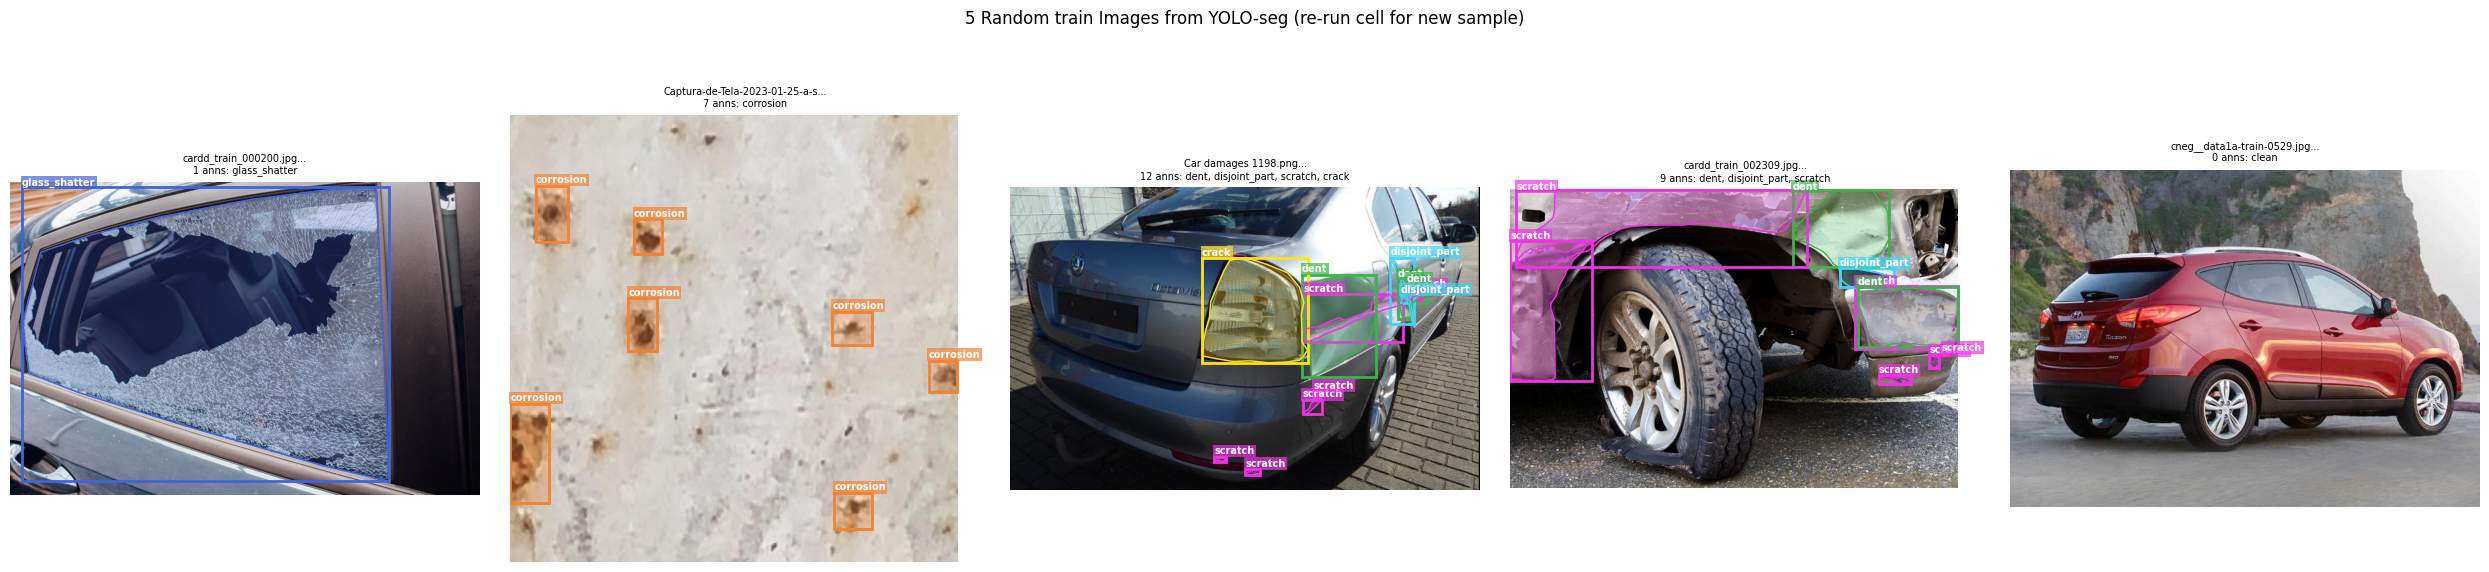

In [158]:
# ─── Cell 11: Visualize 5 Random YOLO-seg Training Images ─────────────────────
import random
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Robust path resolution (works whether run from src/ or project root)
if Path("../data/processed/yolo_seg").exists():
    YOLO_DIR = Path("../data/processed/yolo_seg")
elif Path("data/processed/yolo_seg").exists():
    YOLO_DIR = Path("data/processed/yolo_seg")
else:
    raise FileNotFoundError("Could not locate 'data/processed/yolo_seg'. Check your working directory.")

SPLIT = "train"

CLASS_COLORS = {
    "broken_lamp":   "#e6194b",
    "corrosion":     "#f58231",
    "crack":         "#ffe119",
    "dent":          "#3cb44b",
    "disjoint_part": "#42d4f4",
    "glass_shatter": "#4363d8",
    "scratch":       "#f032e6",
}
UNIFIED_CLASSES = ["broken_lamp", "corrosion", "crack", "dent", "disjoint_part", "glass_shatter", "scratch"]

img_dir = YOLO_DIR / "images" / SPLIT
lbl_dir = YOLO_DIR / "labels" / SPLIT

# Get all image files
img_files = sorted([p for p in img_dir.iterdir() if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}])

if not img_files:
    print(f"No images found in {img_dir}")
else:
    # Pick 5 random images (different every run)
    sample = random.sample(img_files, min(5, len(img_files)))

    fig, axes = plt.subplots(1, 5, figsize=(25, 6))
    if len(sample) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, sample):
        img = Image.open(img_path).convert("RGB")
        w_img, h_img = img.size
        ax.imshow(img)

        # Find corresponding YOLO label file
        lbl_path = lbl_dir / (img_path.stem + ".txt")
        anns = []
        classes_present = set()
        
        # Parse YOLO-seg format: class_id x1 y1 x2 y2 ... (normalized 0-1)
        if lbl_path.exists() and lbl_path.stat().st_size > 0:
            with open(lbl_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 7:  # class_id + at least 3 points (6 coords)
                        continue
                    cls_id = int(parts[0])
                    if cls_id >= len(UNIFIED_CLASSES):
                        continue
                        
                    cls_name = UNIFIED_CLASSES[cls_id]
                    classes_present.add(cls_name)
                    
                    # Un-normalize coordinates to pixel space
                    coords = [float(x) for x in parts[1:]]
                    xs = [coords[i] * w_img for i in range(0, len(coords), 2)]
                    ys = [coords[i] * h_img for i in range(1, len(coords), 2)]
                    
                    color = CLASS_COLORS.get(cls_name, "#ffffff")
                    
                    # Draw polygon fill and outline
                    ax.fill(xs, ys, alpha=0.25, color=color)
                    ax.plot(xs + [xs[0]], ys + [ys[0]], color=color, linewidth=1)
                    
                    # Draw bounding box (derived from polygon extents)
                    min_x, max_x = min(xs), max(xs)
                    min_y, max_y = min(ys), max(ys)
                    rect = patches.Rectangle((min_x, min_y), max_x - min_x, max_y - min_y, 
                                             linewidth=2, edgecolor=color, facecolor="none")
                    ax.add_patch(rect)
                    ax.text(min_x, max(min_y - 4, 0), cls_name, color="white", fontsize=7,
                            fontweight="bold", bbox=dict(facecolor=color, alpha=0.7, edgecolor="none", pad=1))
                    
                    anns.append(cls_name)

        n_anns = len(anns)
        title_text = f"{img_path.name[:30]}...\n{n_anns} anns: {', '.join(classes_present) if classes_present else 'clean'}"
        ax.set_title(title_text, fontsize=7)
        ax.axis("off")

    plt.suptitle(f"5 Random {SPLIT} Images from YOLO-seg (re-run cell for new sample)", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()